In [1]:
# Set to true to run models with simple hyperparameters and fewer epochs for testing purposes
TESTING_ARCHITECTURE = True

In [2]:
import pandas as pd
import sys
import os

sys.path.append("../model-experimentation/data-preprocessing")
import prepare_file

sys.path.pop()

# load data set
clean_dataset_file = "../Clean_NPFC-Test_Database_V2.csv"

if not os.path.isfile(clean_dataset_file):
    prepare_file.generate_prepared_file(clean_dataset_file)
df = pd.read_csv(clean_dataset_file)

relevant_columns = [
    "Subject_ID",
    "Timestamp",
    "Test_Time",
    "Task_Num",
    "Task_Time",
    "Task_Type",
    "Frame",
    "Task_Frame",
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Face_Detection",
    "resmasknet_anger_aligned",
    "resmasknet_disgust_aligned",
    "resmasknet_fear_aligned",
    "resmasknet_happiness_aligned",
    "resmasknet_sadness_aligned",
    "resmasknet_surprise_aligned",
    "resmasknet_neutral_aligned",
    "resmasknet_max_emotion_value",
    "Temperature_aligned",
    "EDA_aligned",
    "BVP_aligned",
    "HeadBandOn",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
    "Gender",
    "Perceived_Tiredness",
    "Perceived_Stress",
    "Wearing_Glasses",
]

df = df[relevant_columns]

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 22105 entries, 0 to 22104
Data columns (total 48 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Subject_ID                    22105 non-null  str    
 1   Timestamp                     22105 non-null  str    
 2   Test_Time                     22105 non-null  str    
 3   Task_Num                      22105 non-null  float64
 4   Task_Time                     22105 non-null  str    
 5   Task_Type                     22105 non-null  int64  
 6   Frame                         22105 non-null  int64  
 7   Task_Frame                    22105 non-null  int64  
 8   Selfreport_valence            22105 non-null  int64  
 9   Selfreport_arousal            22105 non-null  int64  
 10  Selfreport_focus              22105 non-null  int64  
 11  Face_Detection                22105 non-null  int64  
 12  resmasknet_anger_aligned      22105 non-null  float64
 13  resmasknet_d

In [3]:
# This is added because when testing with low iterations, some models throw convergence warnings, makes it impossible to see outputs
if TESTING_ARCHITECTURE:
    import warnings

    warnings.filterwarnings("ignore")

# Random Forest model training


## Feature scaling and selection

Selecting the best features (X).
Also creating the features for prediction (Y).


In [4]:
# Select relevant features
feature_columns = [
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Temperature_aligned",
    "EDA_aligned",
    "BVP_aligned",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
    "Gender",
    "Perceived_Tiredness",
    "Perceived_Stress",
    "Wearing_Glasses",
]

feature_df = df[feature_columns]

# Output the results of the feature selection
feature_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22105 entries, 0 to 22104
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Selfreport_valence   22105 non-null  int64  
 1   Selfreport_arousal   22105 non-null  int64  
 2   Selfreport_focus     22105 non-null  int64  
 3   Temperature_aligned  21774 non-null  float64
 4   EDA_aligned          21792 non-null  float64
 5   BVP_aligned          21767 non-null  float64
 6   Delta_TP9            22105 non-null  float64
 7   Delta_AF7            22105 non-null  float64
 8   Delta_AF8            22105 non-null  float64
 9   Delta_TP10           22105 non-null  float64
 10  Theta_TP9            22105 non-null  float64
 11  Theta_AF7            22105 non-null  float64
 12  Theta_AF8            22105 non-null  float64
 13  Theta_TP10           22105 non-null  float64
 14  Alpha_TP9            22105 non-null  float64
 15  Alpha_AF7            22105 non-null  float64
 1

In [5]:
### Data normalization preprocessor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, MinMaxScaler

# All physiological signals, brainwave bands, and temperature
sensor_and_eeg_features = [
    "Temperature_aligned",
    "EDA_aligned",
    "BVP_aligned",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
]

# Subjective human ratings
survey_features = [
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Perceived_Tiredness",
    "Perceived_Stress",
]

# Metadata/Demographics left untouched
binary_features = ["Gender", "Wearing_Glasses"]

# Robust pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("robust_sensors", RobustScaler(), sensor_and_eeg_features),
        ("minmax_survey", MinMaxScaler(), survey_features),
        ("pass_binary", "passthrough", binary_features),
    ]
)

# HOW TO USE:
# X_train_scaled = preprocessor.fit_transform(X_train)
# X_test_scaled = preprocessor.transform(X_test)

## Model creation and training

Here we are tranining the regression model. In particular, a random forest model. This model will predict the uncertainty of the resmasknet FER model.


In [6]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Convert all variables to float to ensure missing values are numpy safe (from pandas.NA to np.nan)
# and also filling any created NaN to avoid downstream scikit-learn estimator failures.
X = feature_df.astype(float).fillna(0)
y = df["resmasknet_max_emotion_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply preprocessor perfectly matching the comment block example
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Extract generated feature names dynamically
feature_names_out = preprocessor.get_feature_names_out()


In [7]:
# --- Random Forest Regressor with RFE Backward Elimination ---
print("--- Random Forest Regressor ---")

if TESTING_ARCHITECTURE:
    rf_reg = RandomForestRegressor(random_state=42, n_estimators=1, n_jobs=-1)
else:
    rf_reg = RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=-1)

# RFECV performs recursive backward elimination and selected best features by CV score
rf_selector = RFECV(estimator=rf_reg, step=0.1, cv=3, scoring="neg_mean_squared_error")
rf_selector.fit(X_train_scaled, y_train)

X_train_rf = rf_selector.transform(X_train_scaled)
X_test_rf = rf_selector.transform(X_test_scaled)

rf_reg.fit(X_train_rf, y_train)
y_pred_rf = rf_reg.predict(X_test_rf)

print(f"Optimal number of features: {rf_selector.n_features_}")
print(f"Selected features: {feature_names_out[rf_selector.support_]}")

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
n_rf = X_test_rf.shape[0]  # type: ignore
p_rf = X_test_rf.shape[1]  # type: ignore
adj_r2_rf = (
    1 - (1 - r2_rf) * (n_rf - 1) / (n_rf - p_rf - 1)
    if (n_rf - p_rf - 1) > 0
    else float("nan")
)

print(f"MSE: {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"R-squared: {r2_rf:.4f}")
print(f"Adjusted R-squared: {adj_r2_rf:.4f}\n")

--- Random Forest Regressor ---
Optimal number of features: 3
Selected features: ['robust_sensors__Temperature_aligned' 'robust_sensors__EDA_aligned'
 'robust_sensors__Gamma_AF8']
MSE: 0.0302
RMSE: 0.1737
MAE: 0.1321
R-squared: -0.1371
Adjusted R-squared: -0.1379



## Feature importance extraction


In [8]:
selected_feature_names = feature_names_out[rf_selector.support_]

rf_importances = rf_reg.feature_importances_
rf_importance_df = pd.DataFrame(
    {"Feature": selected_feature_names, "Importance": rf_importances}
).sort_values(by="Importance", ascending=False)

print(rf_importance_df)

                               Feature  Importance
1          robust_sensors__EDA_aligned    0.414092
0  robust_sensors__Temperature_aligned    0.318927
2            robust_sensors__Gamma_AF8    0.266981


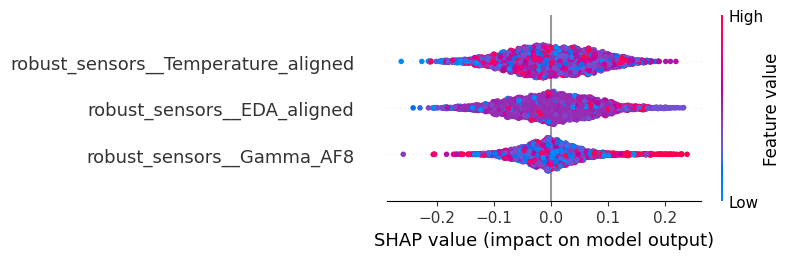

In [9]:
# SHAP (SHapley Additive exPlanations)
import shap

# 1. Summarize the background data so the explainer runs in seconds, not hours
background_data = shap.sample(X_train_rf, 50)

# 2. Create an explainer for the Random Forest model
# Note: We use X_train_rf because the model was trained on the reduced feature set
explainer = shap.TreeExplainer(rf_reg)

# 3. Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_rf)

# 4. Plot the summary
# We pass the selected feature names so the plot is readable
shap.summary_plot(shap_values, X_test_rf, feature_names=selected_feature_names)

# Linear mixed model (LMM) training


## Feature scaling and selection


In [10]:
# Select relevant features. For LMM we include Subject_ID and Task_Num as features to allow for random effects
feature_columns = [
    "Subject_ID",
    "Task_Num",
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Temperature_aligned",
    "EDA_aligned",
    "BVP_aligned",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
    "Gender",
    "Perceived_Tiredness",
    "Perceived_Stress",
    "Wearing_Glasses",
]

feature_df = df[feature_columns]

# feature_df["Subject_ID"] = feature_df["Subject_ID"].map(
#     lambda x: x.replace("IFE-EC-NPFC-T003-", "").strip()  # type: ignore
# )


In [11]:
### Data normalization preprocessor

# All physiological signals, brainwave bands, and temperature
sensor_and_eeg_features = [
    "Temperature_aligned",
    "EDA_aligned",
    "BVP_aligned",
    "Delta_TP9",
    "Delta_AF7",
    "Delta_AF8",
    "Delta_TP10",
    "Theta_TP9",
    "Theta_AF7",
    "Theta_AF8",
    "Theta_TP10",
    "Alpha_TP9",
    "Alpha_AF7",
    "Alpha_AF8",
    "Alpha_TP10",
    "Beta_TP9",
    "Beta_AF7",
    "Beta_AF8",
    "Beta_TP10",
    "Gamma_TP9",
    "Gamma_AF7",
    "Gamma_AF8",
    "Gamma_TP10",
]

categorical_cols = [
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Perceived_Tiredness",
    "Perceived_Stress",
    "Gender",
    "Wearing_Glasses",
    "Subject_ID",
    "Task_Num",
]

# Robust pipeline
preprocessor_lmm = ColumnTransformer(
    transformers=[
        ("robust_sensors", RobustScaler(), sensor_and_eeg_features),
        ("passthrough", "passthrough", categorical_cols),
    ],
    verbose_feature_names_out=False,
)

In [ ]:
import statsmodels.formula.api as smf
import scipy.stats as stats
import pandas as pd

y_certainty = df["resmasknet_max_emotion_value"]
lmm_x = preprocessor_lmm.fit_transform(feature_df)
col_names = preprocessor_lmm.get_feature_names_out()
lmm_x = pd.DataFrame(np.array(lmm_x), columns=col_names)

# Add target and grouping variables from the main df using the exact column names
lmm_x["certainty"] = y_certainty.values
lmm_x.reset_index(drop=True, inplace=True)

# Dynamically construct the formula string (predicting certainty)
categorical_features = [
    "Selfreport_valence",
    "Selfreport_arousal",
    "Selfreport_focus",
    "Perceived_Tiredness",
    "Perceived_Stress",
    "Gender",
    "Wearing_Glasses",
]
numerical_features = sensor_and_eeg_features
formatted_categorical_features = [f"C({col})" for col in categorical_features]

fixed_effects_formula = "certainty ~ " + " + ".join(
    numerical_features + formatted_categorical_features
)
print(fixed_effects_formula)


certainty ~ Temperature_aligned + EDA_aligned + BVP_aligned + Delta_TP9 + Delta_AF7 + Delta_AF8 + Delta_TP10 + Theta_TP9 + Theta_AF7 + Theta_AF8 + Theta_TP10 + Alpha_TP9 + Alpha_AF7 + Alpha_AF8 + Alpha_TP10 + Beta_TP9 + Beta_AF7 + Beta_AF8 + Beta_TP10 + Gamma_TP9 + Gamma_AF7 + Gamma_AF8 + Gamma_TP10 + C(Selfreport_valence) + C(Selfreport_arousal) + C(Selfreport_focus) + C(Perceived_Tiredness) + C(Perceived_Stress) + C(Gender) + C(Wearing_Glasses)


In [ ]:
# --- Linear Mixed-Effects Model Fit ---
print("--- Linear Mixed-Effects Model Fit ---")


lmm_model = smf.mixedlm(
    fixed_effects_formula,
    data=lmm_x,
    groups=lmm_x["Subject_ID"],
    vc_formula={"task_num": "0 + C(Task_Num)"},  # Use Task_Num as random effect
)
lmm_results = lmm_model.fit()
print(lmm_results.summary())

--- Linear Mixed-Effects Model Fit ---


: 

In [ ]:
# --- Statistical Assumption Verification ---
print("--- Validation of LMM Residuals ---")

model_residuals = lmm_results.resid

# Check residual normality (sampled to 5000 if dataset size is large for Shapiro test scalability)
if len(model_residuals) > 5000:
    shapiro_sample = model_residuals.sample(5000, random_state=42)
    stat, p_value = stats.shapiro(shapiro_sample)
    print(
        f"Shapiro-Wilk Test (Sampled N=5000) - Statistic: {stat:.4f}, p-value: {p_value:.4e}"
    )
else:
    stat, p_value = stats.shapiro(model_residuals)
    print(f"Shapiro-Wilk Test - Statistic: {stat:.4f}, p-value: {p_value:.4e}")

print(f"Residuals Skewness: {stats.skew(model_residuals):.4f}")
print(f"Residuals Kurtosis: {stats.kurtosis(model_residuals):.4f}")

--- Validation of LMM Residuals ---
Shapiro-Wilk Test (Sampled N=5000) - Statistic: 0.9935, p-value: 2.4709e-14
Residuals Skewness: -0.1744
Residuals Kurtosis: -0.4123


# Final Figure Generation for Results Section

Creating composite figures combining Random Forest predictive power (SHAP)
and LMM structural explanation (Forest/Caterpillar plots).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import shap
import statsmodels.api as sm

# Set publication-quality style parameters
plt.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.dpi": 300,  # High resolution for paper
        "savefig.bbox": "tight",
    }
)

### Figure 1: The Predictive and Explanatory Front (Global Effects)

Note: Because SHAP uses its own complex matplotlib rendering, it's safer to save it
as a standalone panel rather than trying to force it into a complex subplot layout.


Generating Figure 1 - Panel A (SHAP)...


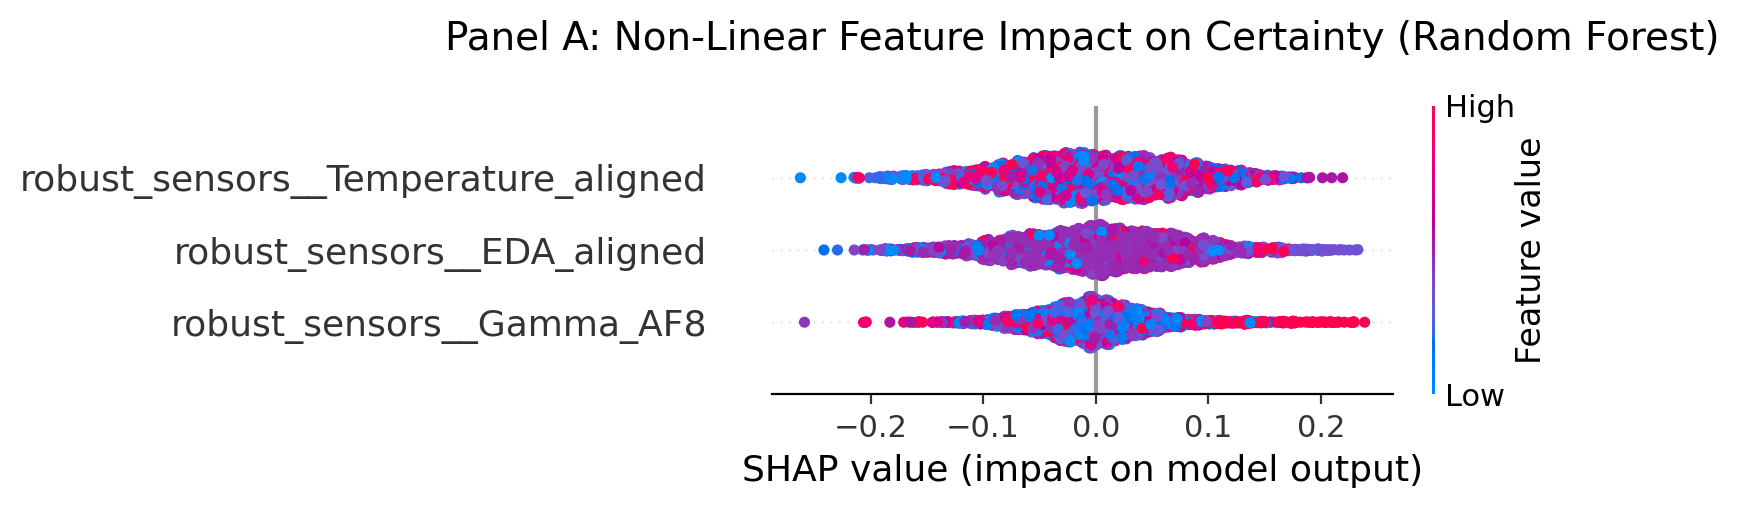

Saved: Fig1_PanelA_SHAP.png


In [ ]:
# ==========================================
# PANEL A: SHAP Summary Plot (Random Forest)
# ==========================================
print("Generating Figure 1 - Panel A (SHAP)...")

# Calculate SHAP values (assuming explainer and X_test_rf are in memory from previous cells)
shap_values = explainer.shap_values(X_test_rf)

plt.figure(figsize=(10, 8))
plt.title("Panel A: Non-Linear Feature Impact on Certainty (Random Forest)", pad=20)
# Force matplotlib backend for saving
shap.summary_plot(
    shap_values, X_test_rf, feature_names=selected_feature_names, show=False
)
plt.savefig("figures/Fig1_PanelA_SHAP.png")
plt.show()
plt.close()

Generating Figure 1 - Panel B (LMM Forest Plot)...


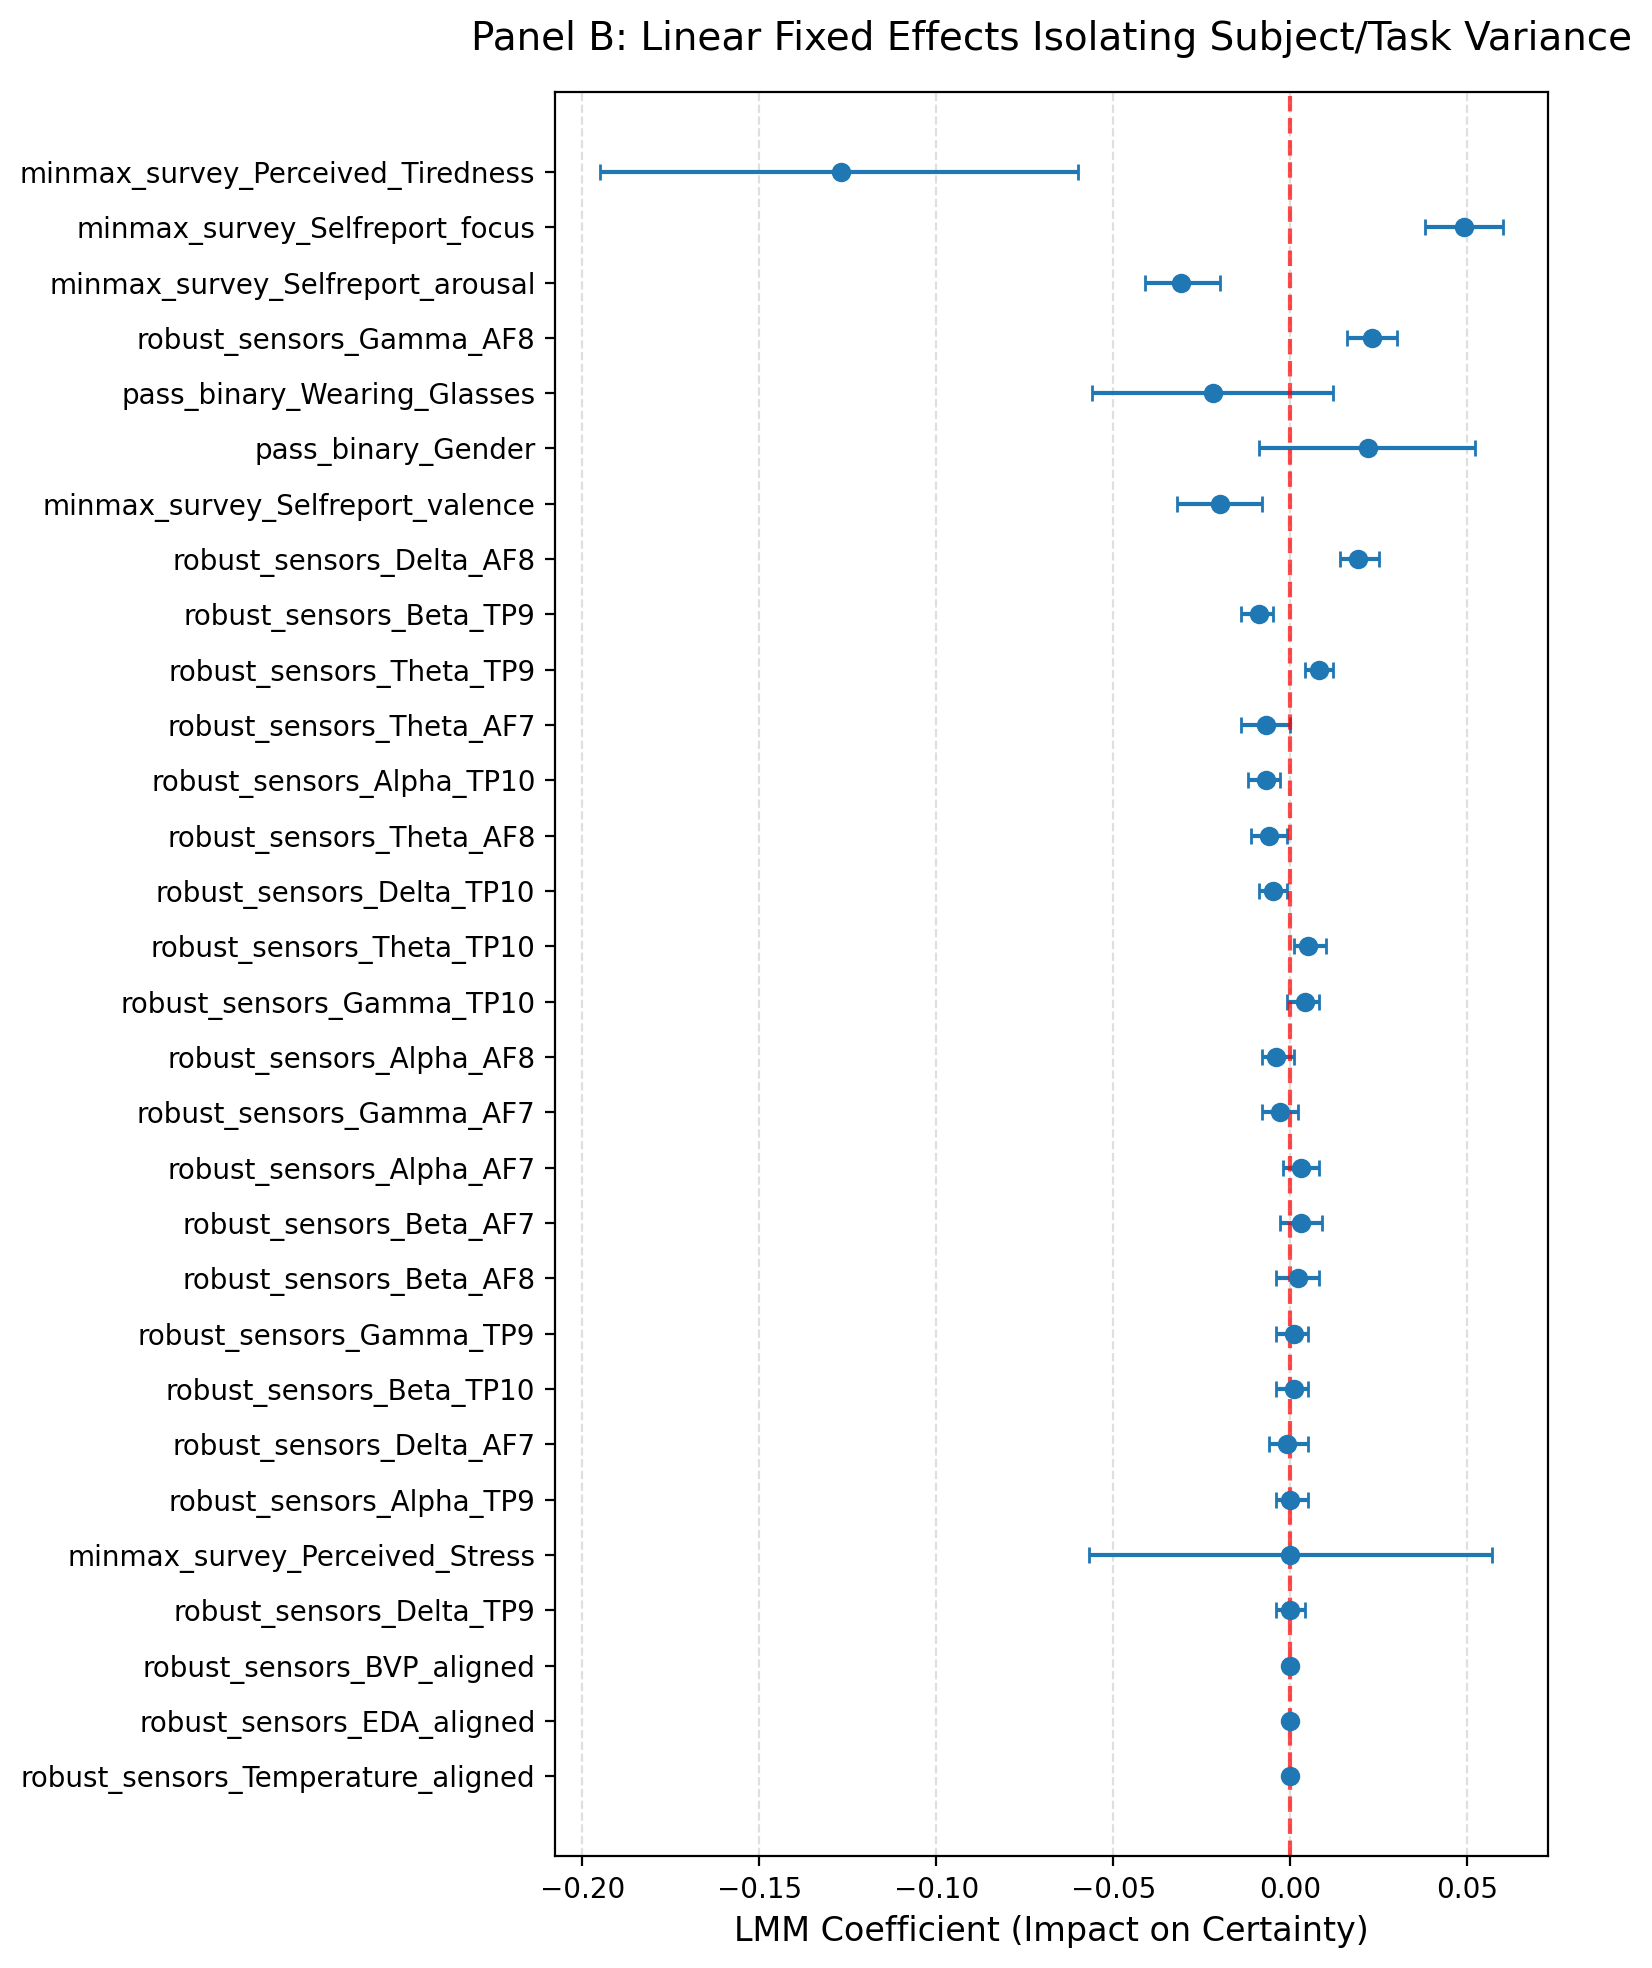

Saved: Fig1_PanelB_LMM_Forest.png


In [ ]:
# ==========================================
# PANEL B: Forest Plot of Fixed Effects (LMM)
# ==========================================
print("Generating Figure 1 - Panel B (LMM Forest Plot)...")

# Extract coefficients, p-values, and confidence intervals from LMM results
# For MixedLM, tables[1] is ALREADY a pandas DataFrame
coef_df = lmm_results.summary().tables[1].copy()

# Clean column names to make them easy to work with
coef_df.columns = ["Coef", "StdErr", "z", "P>|z|", "CI_Lower", "CI_Upper"]

# Convert all values to numeric (statsmodels sometimes stores them as object/string)
coef_df = coef_df.apply(pd.to_numeric, errors="coerce").dropna()

# Remove the Intercept and variance components for cleaner visualization
if "Intercept" in coef_df.index:
    coef_df = coef_df.drop("Intercept")

# The variance component might be named 'task_context Var', so we filter out any 'Var'
coef_df = coef_df[~coef_df.index.str.contains("Var")]

# Sort by absolute coefficient value for better readability (similar to SHAP)
coef_df["abs_coef"] = coef_df["Coef"].abs()
coef_df = coef_df.sort_values(by="abs_coef", ascending=True)

# Create the Forest Plot
fig, ax = plt.subplots(figsize=(8, 10))

# Plot confidence intervals as horizontal error bars
y_pos = np.arange(len(coef_df))
ax.errorbar(
    coef_df["Coef"],
    y_pos,
    xerr=[coef_df["Coef"] - coef_df["CI_Lower"], coef_df["CI_Upper"] - coef_df["Coef"]],
    fmt="o",
    color="#1f77b4",
    ecolor="#1f77b4",
    capsize=3,
    markersize=6,
)

# Add a vertical reference line at zero
ax.axvline(x=0, color="red", linestyle="--", alpha=0.7)

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_df.index)
ax.set_xlabel("LMM Coefficient (Impact on Certainty)")
ax.set_title("Panel B: Linear Fixed Effects Isolating Subject/Task Variance", pad=15)
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("figures/Fig1_PanelB_LMM_Forest.png")
plt.show()
plt.close()

### Figure 2: The Impact of Context (Crossed Random Effects)


Generating Figure 2 (Caterpillar Plot for Tasks)...


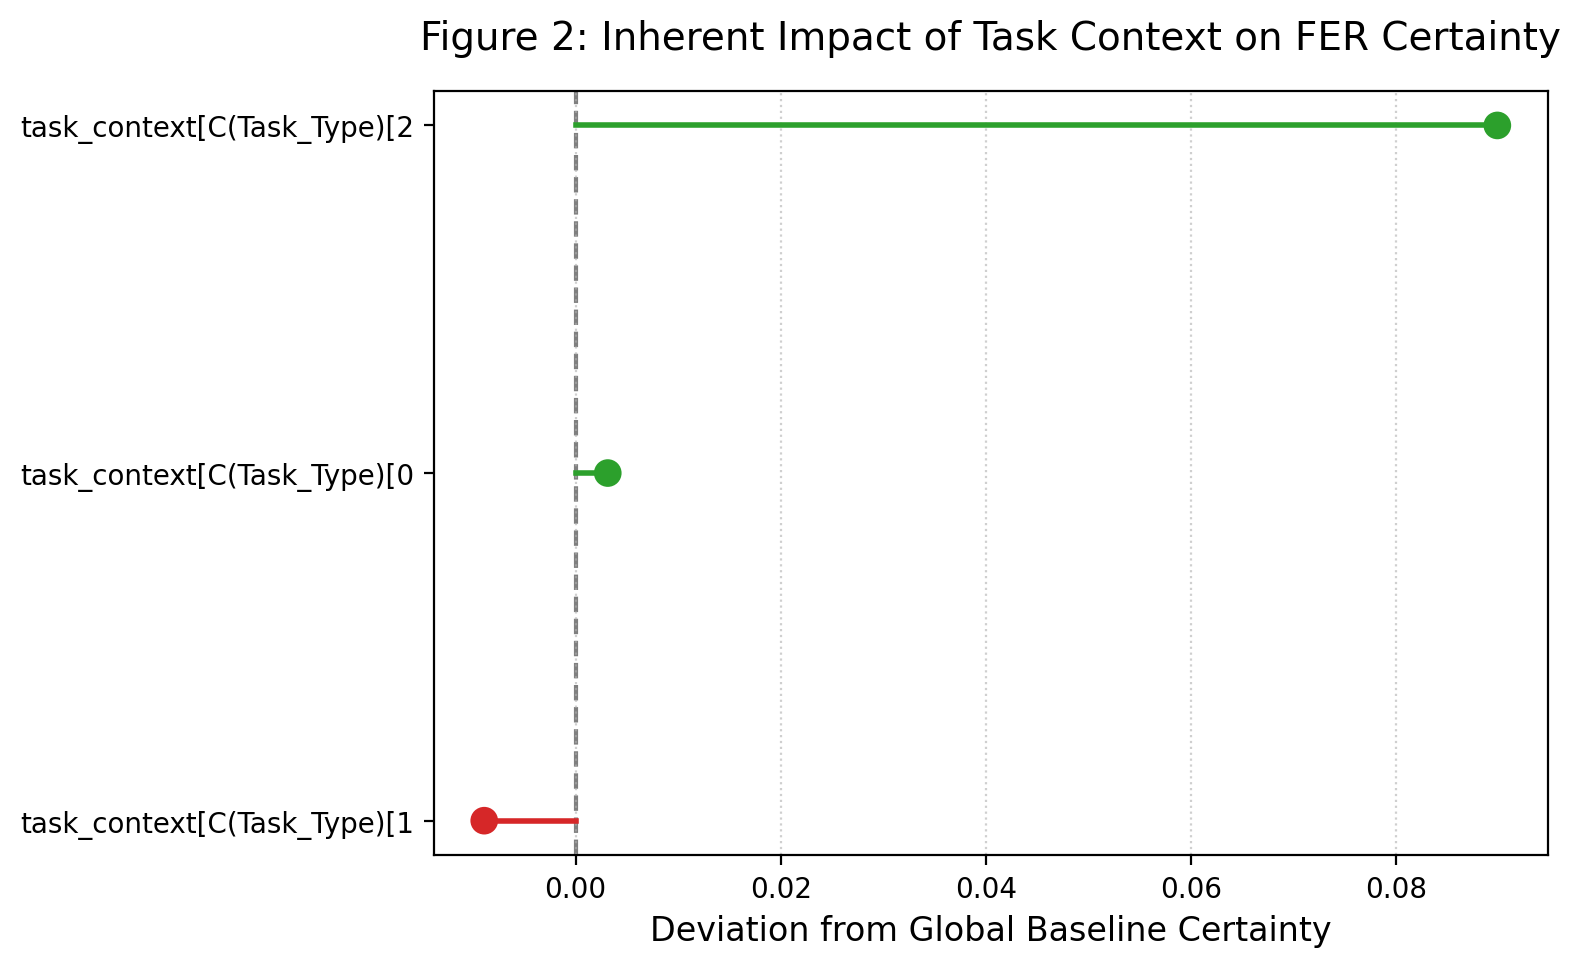

Saved: Fig2_Caterpillar_Task.png
All figures generated successfully.


In [ ]:
# ==========================================
# FIGURE 2: Caterpillar Plot for Task_Type
# ==========================================
print("Generating Figure 2 (Caterpillar Plot for Tasks)...")

# Extract Random Effects for Tasks
# statsmodels stores random effects in a dictionary: result.random_effects
# The keys are the groups (Subject_ID), but since we used crossed effects via vc_formula,
# we have to extract the variance components carefully.

# Create a clean DataFrame of the random effects
re_dict = lmm_results.random_effects
# The structure for crossed effects in statsmodels is usually tied to the main group,
# but the vcomp elements contain the specific levels. We extract them dynamically:

task_effects = {}
for subject, effects in re_dict.items():
    for name, value in effects.items():
        if "task_context" in name:
            # Extract the actual task name from the string like 'task_context[T.TaskName]'
            clean_name = name.split("[T.")[-1].replace("]", "")
            # LMM assumes the same random effect value for a task across all subjects
            if clean_name not in task_effects:
                task_effects[clean_name] = value

# Convert to DataFrame and sort
task_df = pd.DataFrame(list(task_effects.items()), columns=["Task", "RandomEffect"])
task_df = task_df.sort_values(by="RandomEffect", ascending=True)

# Create the Caterpillar Plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the points
y_pos_task = np.arange(len(task_df))
colors = ["#d62728" if x < 0 else "#2ca02c" for x in task_df["RandomEffect"]]
ax.scatter(task_df["RandomEffect"], y_pos_task, color=colors, s=80, zorder=3)

# Add stems/lines to the zero axis
for i, value in enumerate(task_df["RandomEffect"]):
    ax.plot([0, value], [i, i], color=colors[i], linestyle="-", linewidth=2, zorder=2)

# Add vertical reference line
ax.axvline(x=0, color="black", linestyle="--", alpha=0.5, zorder=1)

# Formatting
ax.set_yticks(y_pos_task)
ax.set_yticklabels(task_df["Task"])
ax.set_xlabel("Deviation from Global Baseline Certainty")
ax.set_title("Figure 2: Inherent Impact of Task Context on FER Certainty", pad=15)
ax.grid(axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("figures/Fig2_Caterpillar_Task.png")
plt.show()
plt.close()